# Drift-adjusted trend report

???? ????? notebook-?: ?????????, ??????? ?? ????????????? ???????? drift, ????????? ?? ???????? ???????????? ???????? ??????? ? 2016 ????,
???? ???????? ??? ??? ????????? ????????? ???? ? ????? ????????? ?????? ?????? ????? baseline.

??????????:
- ???????? `ema_plus_key + ridge`;
- `drift-adjusted ridge`, ??? ?????? ?????? ?? ???????? ?????? ?????????????? ?????????? baseline;
- ??? drift-only baseline;
- naive last value ??? ?????? ????????.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'cashflow' / 'market' / 'trend' / 'trend_research_utils.py').exists():
        ROOT = candidate
        break

if ROOT is None:
    raise RuntimeError('Could not locate repository root from current working directory')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cashflow.market.trend.trend_research_utils import (
    DEFAULT_TREND_WINDOWS,
    build_key_rate_feature_frame,
    build_model_pipeline,
    build_trend_feature_frame,
    generate_test_positions,
    load_trend_panel,
    quarter_to_idx,
    regression_metrics,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

panel = load_trend_panel(ROOT)
panel['quarter_label'] = panel['quarter_norm'].astype(str)
panel['x'] = np.arange(len(panel), dtype=int)
target_col = 'market_log_level_q'
y = panel[target_col].to_numpy(dtype=float)
anchor_quarter = '2016Q1'
anchor_order = quarter_to_idx(anchor_quarter)

trend_template = build_trend_feature_frame(y, test_start=1, test_end=2, windows=DEFAULT_TREND_WINDOWS)
ema_cols = [c for c in trend_template.columns if c.startswith('ema_')]
key_rate_frame = build_key_rate_feature_frame(panel).reset_index(drop=True)
feature_cols = ema_cols + list(key_rate_frame.columns)

print(f'Panel rows: {len(panel)}')
print(f'Quarter range: {panel.quarter_norm.iloc[0]} -> {panel.quarter_norm.iloc[-1]}')
print(f'Anchor quarter: {anchor_quarter}')
print(f'EMA columns: {ema_cols}')
print(f'Key-rate columns: {list(key_rate_frame.columns)}')
print(f'Feature count: {len(feature_cols)}')

Panel rows: 45
Quarter range: 2015Q1 -> 2026Q1
Anchor quarter: 2016Q1
EMA columns: ['ema_3', 'ema_6', 'ema_10']
Key-rate columns: ['key_rate_avg_q', 'key_rate_eoq', 'key_rate_min_q', 'key_rate_max_q', 'key_rate_log_return_q', 'key_rate_qoq_change', 'key_rate_spread_q', 'key_rate_ma_4', 'key_rate_ema_4', 'key_rate_ma_8', 'key_rate_ema_8']
Feature count: 14


## 1. ??????? ??????? ? 2016 ????

??????? ??????? ?? ??? quarterly `log(market)` growth.
??????? ????? ?? ??????? ? ??????? ??????????? ???????, ????????? ?? ???? ????????? ????????? ??????? ? `2016Q1`.

Mean quarterly growth since 2016Q1: 0.02683 log-points per quarter


,quarter_norm,market_log_ret_q,rolling_4q
4,2016Q1,-0.044564,-0.044564
5,2016Q2,-0.002916,-0.023740
6,2016Q3,0.036313,-0.003723
7,2016Q4,-0.005222,-0.004097
8,2017Q1,-0.001836,0.006585
9,2017Q2,0.015526,0.011195
10,2017Q3,-0.005532,0.000734
11,2017Q4,0.003149,0.002827


,quarter_norm,market_log_ret_q,rolling_4q
37,2024Q2,0.050243,0.048470
38,2024Q3,-0.023294,0.028387
39,2024Q4,0.005057,0.014304
40,2025Q1,0.019881,0.012972
41,2025Q2,0.043680,0.011331
42,2025Q3,0.058582,0.031800
43,2025Q4,0.083352,0.051374
44,2026Q1,0.051099,0.059178


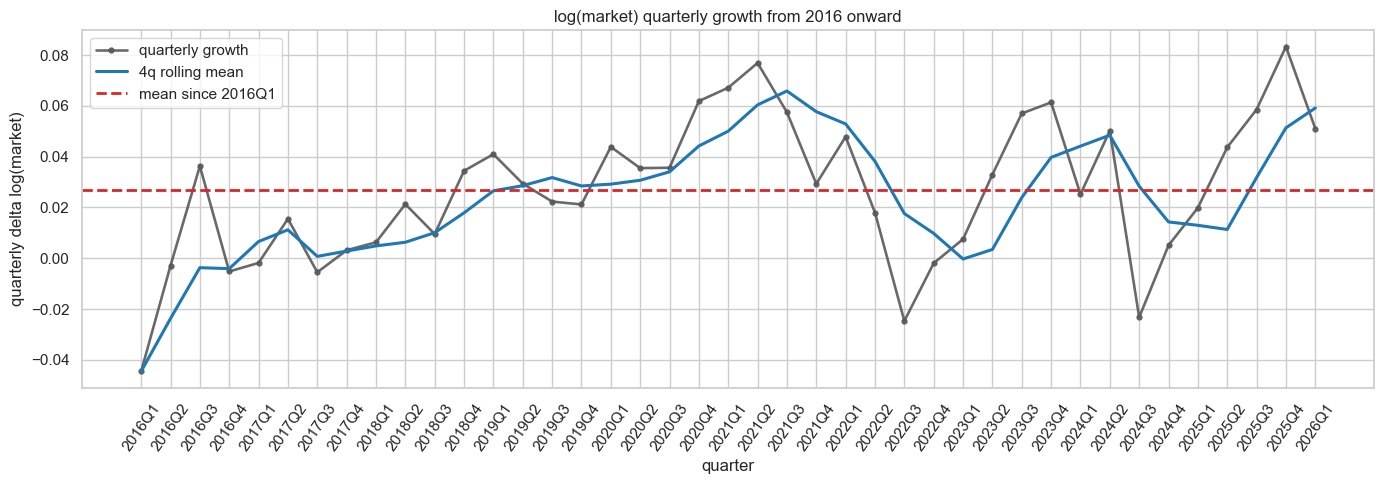

In [2]:
growth_panel = panel.loc[panel['quarter_order'] >= anchor_order, ['quarter_norm', 'x', target_col, 'market_log_ret_q']].copy()
growth_panel['rolling_4q'] = growth_panel['market_log_ret_q'].rolling(4, min_periods=1).mean()
global_mean_growth = growth_panel['market_log_ret_q'].mean()

print(f"Mean quarterly growth since {anchor_quarter}: {global_mean_growth:.5f} log-points per quarter")
display(growth_panel[['quarter_norm', 'market_log_ret_q', 'rolling_4q']].head(8))
display(growth_panel[['quarter_norm', 'market_log_ret_q', 'rolling_4q']].tail(8))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(growth_panel['quarter_norm'], growth_panel['market_log_ret_q'], color='0.35', lw=1.9, marker='o', ms=3.5, alpha=0.9, label='quarterly growth')
ax.plot(growth_panel['quarter_norm'], growth_panel['rolling_4q'], color='#1f77b4', lw=2.2, label='4q rolling mean')
ax.axhline(global_mean_growth, color='#d62728', lw=2.0, ls='--', label=f'mean since {anchor_quarter}')
ax.set_title('log(market) quarterly growth from 2016 onward')
ax.set_ylabel('quarterly delta log(market)')
ax.set_xlabel('quarter')
ax.tick_params(axis='x', rotation=55)
ax.legend(loc='best', frameon=True)
fig.tight_layout()
plt.show()

## 2. Drift baseline

?? ?????? blocked-CV ???? ?? ?????? fixed-slope baseline:

- slope = ??????? ??????????? ???????, ????????? ?????? ?? train-????????? ??????? ? `2016Q1`;
- intercept = ??????? ??????? train-?????? ????? ?????? ????? slope;
- ?????? ?????? ?????? ?????? ?? ???????? ?????? ????? baseline.

??? drift ?????????? ????????? ????????? ??????, ? ridge ?????? ??? ?? ??????????? ?? ????.

In [3]:
def estimate_drift_baseline(panel: pd.DataFrame, y: np.ndarray, train_mask: np.ndarray, anchor_order: int):
    x = panel['quarter_order'].to_numpy(dtype=float)
    anchor_mask = (panel['quarter_order'].to_numpy(dtype=int) >= anchor_order) & train_mask

    pair_mask = anchor_mask[1:] & anchor_mask[:-1]
    diffs = y[1:][pair_mask] - y[:-1][pair_mask]
    drift = float(np.nanmean(diffs)) if len(diffs) else 0.0

    t_rel = x - anchor_order
    if anchor_mask.any():
        intercept = float(np.mean(y[anchor_mask] - drift * t_rel[anchor_mask]))
    elif train_mask.any():
        intercept = float(np.mean(y[train_mask]))
    else:
        intercept = float(np.mean(y))

    baseline = intercept + drift * t_rel
    return baseline, drift, intercept


def make_split_data(test_start: int, test_end: int):
    trend_frame = build_trend_feature_frame(y, test_start=test_start, test_end=test_end, windows=DEFAULT_TREND_WINDOWS)
    ema_frame = trend_frame[ema_cols].reset_index(drop=True)
    X = pd.concat([ema_frame, key_rate_frame], axis=1)

    train_mask = np.ones(len(panel), dtype=bool)
    train_mask[test_start:test_end] = False
    test_mask = ~train_mask

    y_train = y[train_mask]
    y_test = y[test_mask]
    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    baseline_full, drift, intercept = estimate_drift_baseline(panel, y, train_mask, anchor_order)
    baseline_train = baseline_full[train_mask]
    baseline_test = baseline_full[test_mask]

    return {
        'trend_frame': trend_frame,
        'X': X,
        'train_mask': train_mask,
        'test_mask': test_mask,
        'y_train': y_train,
        'y_test': y_test,
        'X_train': X_train,
        'X_test': X_test,
        'baseline_full': baseline_full,
        'baseline_train': baseline_train,
        'baseline_test': baseline_test,
        'drift': drift,
        'intercept': intercept,
    }

## 3. Blocked CV: original ridge vs drift-adjusted ridge

???????? ???? ??????? ??????????? ?? fit.
??? drift-baseline slope ? intercept ??????????? ?????? ?? train-????? ??????? ????.

In [4]:
positions = generate_test_positions(len(panel), test_frac=0.30, n_positions=10)
results = []
pred_rows = []
drift_rows = []

for pos_idx, (test_start, test_end) in enumerate(positions):
    split = make_split_data(test_start, test_end)
    y_test = split['y_test']
    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    baseline_train = split['baseline_train']
    baseline_test = split['baseline_test']
    baseline_full = split['baseline_full']
    train_mask = split['train_mask']
    test_mask = split['test_mask']
    drift = split['drift']
    intercept = split['intercept']

    orig_pipe = build_model_pipeline('ridge')
    orig_pipe.fit(X_train, y_train)
    orig_pred = orig_pipe.predict(X_test)

    drift_pipe = build_model_pipeline('ridge')
    drift_pipe.fit(X_train, y_train - baseline_train)
    drift_pred = baseline_test + drift_pipe.predict(X_test)

    drift_only_pred = baseline_test.copy()
    naive_pred = np.full(len(y_test), y[test_start - 1] if test_start > 0 else y[0], dtype=float)

    rows = [
        ('original_ridge', orig_pred),
        ('drift_adjusted_ridge', drift_pred),
        ('drift_only', drift_only_pred),
        ('naive_last_value', naive_pred),
    ]

    for variant, y_pred in rows:
        results.append(
            regression_metrics(y_test, y_pred, name=variant, scope=f'pos_{pos_idx:02d}')
            .assign(
                pos_idx=pos_idx,
                test_start=test_start,
                test_end=test_end,
                variant=variant,
            )
        )

    x_test = panel.loc[test_mask, 'x'].to_numpy()
    quarter_test = panel.loc[test_mask, 'quarter_norm'].to_numpy()

    pred_rows.append(
        pd.DataFrame(
            {
                'pos_idx': pos_idx,
                'test_start': test_start,
                'test_end': test_end,
                'quarter_norm': quarter_test,
                'x': x_test,
                'variant': 'original_ridge',
                'y_true': y_test,
                'y_pred': orig_pred,
                'drift_baseline': baseline_test,
                'drift_per_q': drift,
                'intercept': intercept,
            }
        )
    )
    pred_rows.append(
        pd.DataFrame(
            {
                'pos_idx': pos_idx,
                'test_start': test_start,
                'test_end': test_end,
                'quarter_norm': quarter_test,
                'x': x_test,
                'variant': 'drift_adjusted_ridge',
                'y_true': y_test,
                'y_pred': drift_pred,
                'drift_baseline': baseline_test,
                'drift_per_q': drift,
                'intercept': intercept,
            }
        )
    )
    pred_rows.append(
        pd.DataFrame(
            {
                'pos_idx': pos_idx,
                'test_start': test_start,
                'test_end': test_end,
                'quarter_norm': quarter_test,
                'x': x_test,
                'variant': 'drift_only',
                'y_true': y_test,
                'y_pred': drift_only_pred,
                'drift_baseline': baseline_test,
                'drift_per_q': drift,
                'intercept': intercept,
            }
        )
    )
    pred_rows.append(
        pd.DataFrame(
            {
                'pos_idx': pos_idx,
                'test_start': test_start,
                'test_end': test_end,
                'quarter_norm': quarter_test,
                'x': x_test,
                'variant': 'naive_last_value',
                'y_true': y_test,
                'y_pred': naive_pred,
                'drift_baseline': baseline_test,
                'drift_per_q': drift,
                'intercept': intercept,
            }
        )
    )

    drift_rows.append(
        {
            'pos_idx': pos_idx,
            'test_start': test_start,
            'test_end': test_end,
            'start_quarter': panel.loc[test_start, 'quarter_norm'],
            'end_quarter': panel.loc[test_end - 1, 'quarter_norm'],
            'drift_per_q': drift,
            'intercept': intercept,
            'baseline_rmse_train': float(np.sqrt(np.mean((y_train - baseline_train) ** 2))) if len(y_train) else np.nan,
        }
    )

results_df = pd.concat(results, ignore_index=True)
pred_df = pd.concat(pred_rows, ignore_index=True)
drift_df = pd.DataFrame(drift_rows)

print('Drift estimates by window:')
display(drift_df.round(5))

Drift estimates by window:


,pos_idx,test_start,test_end,start_quarter,end_quarter,drift_per_q,intercept,baseline_rmse_train
0,0,0,14,2015Q1,2018Q2,0.03560,11.65363,0.05108
1,1,3,17,2015Q4,2019Q1,0.03567,11.65136,0.29199
2,2,7,21,2016Q4,2020Q1,0.03495,11.70056,0.29037
3,3,10,24,2017Q3,2020Q4,0.02870,11.86906,0.22068
4,4,14,28,2018Q3,2021Q4,0.02124,12.01489,0.20199
5,5,17,31,2019Q2,2022Q3,0.02499,11.90856,0.21797
6,6,21,35,2020Q2,2023Q3,0.02330,11.91868,0.22419
7,7,24,38,2021Q1,2024Q2,0.02654,11.84383,0.23467
8,8,28,42,2022Q1,2025Q2,0.03069,11.78739,0.25435
9,9,31,45,2022Q4,2026Q1,0.02592,11.85288,0.23165


## 4. Summary

??????? ??????: ???????? ?? drift-adjusted baseline ??????? out-of-block RMSE ?? ????????? ? ???????? ridge?

,R2,MAE_log,RMSE_log
variant,,,
drift_only,-1.8974,0.1137,0.1382
original_ridge,-20.7665,0.2487,0.2913
naive_last_value,-11.8063,0.2767,0.3111
drift_adjusted_ridge,-45.5234,0.2817,0.3330


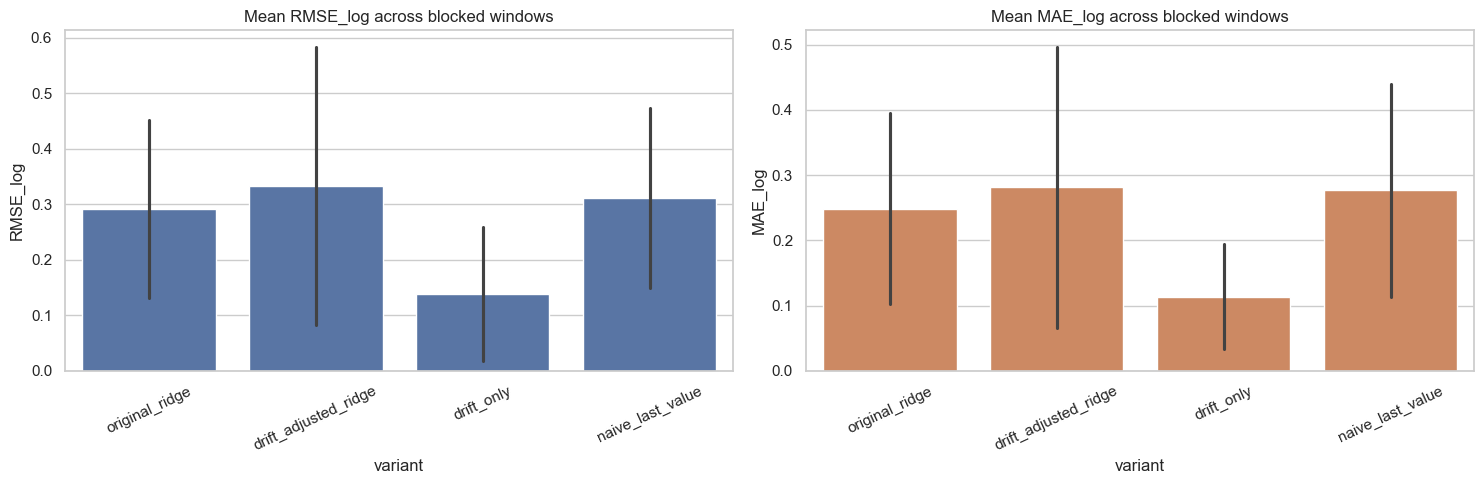

RMSE improvement from drift adjustment: -0.0417 log-points


variant,drift_adjusted_ridge,drift_only,naive_last_value,original_ridge
pos_idx,,,,
0,0.6707,0.4617,0.6996,0.2001
1,0.8126,0.1780,0.3704,0.4548
2,0.2676,0.0708,0.1090,0.5306
3,0.1336,0.1197,0.1766,0.3438
4,0.1496,0.1425,0.3103,0.1994
5,0.1857,0.0895,0.3468,0.1644
6,0.1960,0.0842,0.3466,0.1088
7,0.1666,0.0903,0.3146,0.1227
8,0.1827,0.0427,0.1901,0.5130


In [5]:
summary = (
    results_df.groupby('variant')[['R2', 'MAE_log', 'RMSE_log']]
    .mean()
    .sort_values(['RMSE_log', 'MAE_log'], ascending=[True, True])
    .round(4)
)
display(summary)

pivot_rmse = results_df.pivot_table(index='pos_idx', columns='variant', values='RMSE_log', aggfunc='mean').sort_index()
pivot_mae = results_df.pivot_table(index='pos_idx', columns='variant', values='MAE_log', aggfunc='mean').sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=results_df, x='variant', y='RMSE_log', ax=axes[0], errorbar='sd', color='#4c72b0')
axes[0].set_title('Mean RMSE_log across blocked windows')
axes[0].tick_params(axis='x', rotation=25)
sns.barplot(data=results_df, x='variant', y='MAE_log', ax=axes[1], errorbar='sd', color='#dd8452')
axes[1].set_title('Mean MAE_log across blocked windows')
axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

drift_gain = summary.loc['original_ridge', 'RMSE_log'] - summary.loc['drift_adjusted_ridge', 'RMSE_log']
print(f'RMSE improvement from drift adjustment: {drift_gain:+.4f} log-points')
display(pivot_rmse.round(4))

## 5. Representative windows

???? ???????? ????????? blocked windows.
?????? ????? ? ??????????? market index.
????? ? ???????? ridge.
??????? ? drift-adjusted ridge.
????? ?????????? ? drift baseline, ?????? ???????? ?????? ?????? ?? ????????.

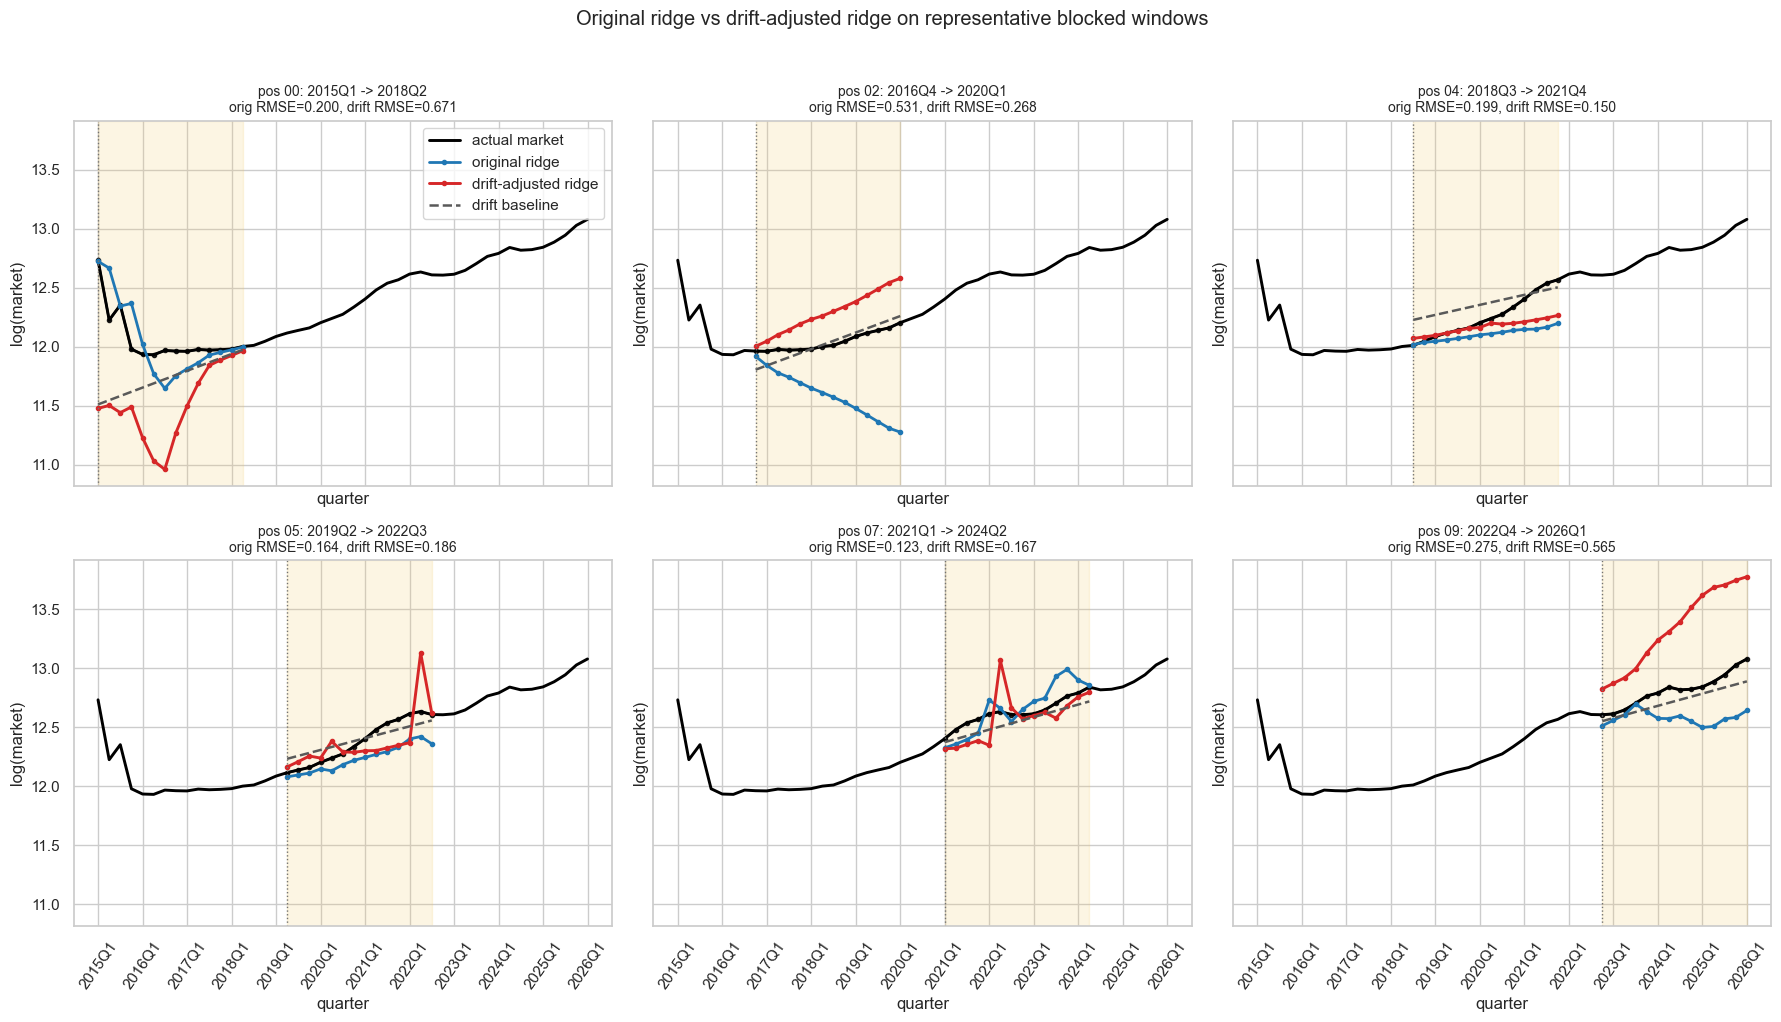

In [6]:
        selected_idx = np.unique(np.round(np.linspace(0, len(positions) - 1, 6)).astype(int))

        fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
        axes = axes.ravel()

        for ax, pos_idx in zip(axes, selected_idx):
            test_start, test_end = positions[pos_idx]
            subset = pred_df[pred_df['pos_idx'] == pos_idx].copy()
            subset = subset.sort_values('x')
            if subset.empty:
                continue

            base = subset[subset['variant'] == 'drift_adjusted_ridge'][['x', 'drift_baseline']].drop_duplicates().sort_values('x')
            orig = subset[subset['variant'] == 'original_ridge'][['x', 'y_pred']].sort_values('x')
            drift_adj = subset[subset['variant'] == 'drift_adjusted_ridge'][['x', 'y_pred']].sort_values('x')
            y_true = subset[['x', 'y_true']].drop_duplicates().sort_values('x')

            start_x = int(y_true['x'].iloc[0])
            end_x = int(y_true['x'].iloc[-1])
            start_q = panel.loc[start_x, 'quarter_norm']
            end_q = panel.loc[end_x, 'quarter_norm']
            rmse_orig = results_df[(results_df['pos_idx'] == pos_idx) & (results_df['variant'] == 'original_ridge')]['RMSE_log'].iloc[0]
            rmse_drift = results_df[(results_df['pos_idx'] == pos_idx) & (results_df['variant'] == 'drift_adjusted_ridge')]['RMSE_log'].iloc[0]

            ax.plot(panel['x'], panel[target_col], color='black', lw=2.1, label='actual market')
            ax.axvspan(start_x, end_x, color='#f3c969', alpha=0.18)
            ax.plot(y_true['x'], y_true['y_true'], color='black', lw=1.7, marker='o', ms=3.0, alpha=0.85)
            ax.plot(orig['x'], orig['y_pred'], color='#1f77b4', lw=2.0, marker='o', ms=3.0, label='original ridge')
            ax.plot(drift_adj['x'], drift_adj['y_pred'], color='#d62728', lw=2.1, marker='o', ms=3.0, label='drift-adjusted ridge')
            ax.plot(base['x'], base['drift_baseline'], color='0.35', lw=1.8, ls='--', label='drift baseline')
            ax.axvline(start_x, color='0.45', ls=':', lw=1.0)
            ax.set_title(
                f'pos {pos_idx:02d}: {start_q} -> {end_q}\n'
                f'orig RMSE={rmse_orig:.3f}, drift RMSE={rmse_drift:.3f}',
                fontsize=10,
            )
            ax.tick_params(axis='x', rotation=55)

        xticks = panel['x'][::4]
        xticklabels = panel['quarter_norm'][::4]
        for ax in axes:
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticklabels, rotation=55)
            ax.set_xlabel('quarter')
            ax.set_ylabel('log(market)')

        axes[0].legend(loc='best', frameon=True)
        fig.suptitle('Original ridge vs drift-adjusted ridge on representative blocked windows', y=1.02)
        fig.tight_layout()
        plt.show()

## Takeaway

???? drift-adjusted ridge ??????? ??????? RMSE, ??? ????? ????????????? ??? ????? ?????????? trend block.
???? ???, ?????? ???????? drift ? ???? ?????????? ??? ?????????? ?????? ??????? ???????? ema-based trend + ridge, ? ?????????? ?????????????? slope ?????? ???????????? ????????.